<a href="https://colab.research.google.com/github/mihikag-tech/UTD-Deep-Dive-AI-Project/blob/Shriya/XGB_troubleshoot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pickle

In [2]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("/content/Combined_dataset_model.csv")
df = pd.get_dummies(df, columns=["biome"], dtype=int)
df = df.drop(columns=['Unnamed: 0'])
print(df.columns)


Index(['county', 'land_area', 'tc_goal', 'treecanopy', 'tc_gap', 'priority_i',
       'pctpocnorm', 'pctpovnorm', 'unemplnorm', 'dep_perc', 'depratnorm',
       'health_nor', 'temp_norm', 'tes', 'tesctyscor', 'rank', 'rankgrpsz',
       'Mean_Temp', 'Median_Temp', 'STD_Temp', 'Min_Temp', 'Max_Temp',
       'Mean_Rain', 'Median_Rain', 'STD_Rain', 'Min_Rain', 'Max_Rain',
       'biome_Desert', 'biome_Forest', 'biome_Grassland'],
      dtype='object')


In [4]:
features = ['land_area', 'treecanopy',
       'priority_i', 'pctpocnorm', 'pctpovnorm', 'unemplnorm', 'dep_perc',
       'depratnorm', 'health_nor', 'tes', 'tesctyscor', 'rank',
       'rankgrpsz', 'Mean_Temp', 'Median_Temp', 'STD_Temp', 'Min_Temp',
       'Max_Temp', 'Mean_Rain', 'Median_Rain', 'STD_Rain', 'Min_Rain',
       'Max_Rain']
target = ['temp_norm']
X_df = df[features]
y_df = df[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, random_state = 42)

In [7]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
}

grid_search = GridSearchCV(
    XGBRegressor(random_state = 42, objective='reg:squarederror'),
    param_grid,
    cv = 5,
    scoring = 'r2'
)

grid_search.fit(X_train, y_train)

print("Best params :", grid_search.best_params_)
print("Best CV acc :", round(grid_search.best_score_, 4))
print("Test acc    :", round(grid_search.best_estimator_.score(X_test, y_test), 4))

Best params : {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300}
Best CV acc : 0.7177
Test acc    : 0.7203


In [8]:
best_model = grid_search.best_estimator_
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
model = XGBRegressor(learning_rate = 0.2, max_depth = 4, n_estimators = 300)
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

print("R2 score:", r2_score(y_test, model_pred))
print("MAE:", mean_absolute_error(y_test, model_pred))




R2 score: 0.7203381061553955
MAE: 0.07041050493717194


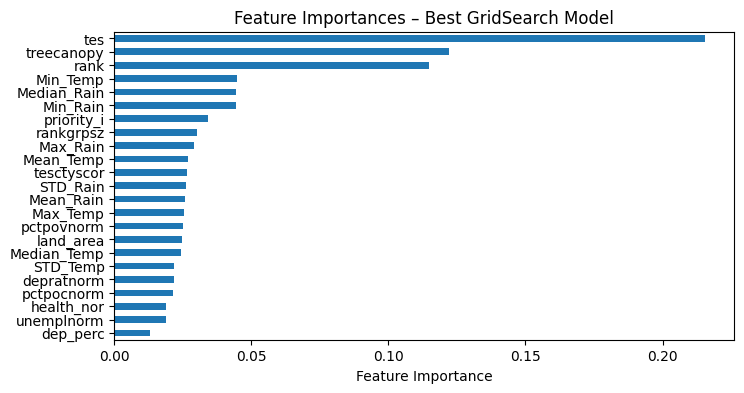

In [7]:
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values()

plt.figure(figsize = (8, 4))
feat_imp.plot(kind = 'barh')
plt.xlabel("Feature Importance")
plt.title("Feature Importances – Best GridSearch Model")
plt.show()


In [8]:
solution_costs = pd.read_csv("/content/Green Intervention Budgets - Sheet1.csv")

In [9]:
# Define what each solution actually changes, and by how much
solution_effects = {
    "green_street": {
        "treecanopy": 1.10,
        "Mean_Temp": 1.15,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Street"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Street"]["avg_sq_feet"].iloc[0])


    },

    "green_parking_lot": {
        "treecanopy": 1.06,
        "Mean_Temp": 1.09,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Parking Lot"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Parking Lot"]["avg_sq_feet"].iloc[0])

    },

    "urban_forest": {
        "treecanopy": 1.2,
        "Mean_Temp": 1.03,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Urban Forest"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Urban Forest"]["avg_sq_feet"].iloc[0])

    },

    "green_roof": {
        "treecanopy": 1.05,
        "Mean_Temp": 1.01,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Roof"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Roof"]["avg_sq_feet"].iloc[0])
    },

    "green_belt": {
        "treecanopy": 1.2,
        "Mean_Temp": 1.1,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Belt"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Belt"]["avg_sq_feet"].iloc[0])
    },

    "park": {
        "treecanopy": 1.14,
        "Mean_Temp": 1.01,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Park"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Park"]["avg_sq_feet"].iloc[0])
    },

    "garden": {
        "treecanopy": 1.03,
        "Mean_Temp": 1.06,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Garden"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Garden"]["avg_sq_feet"].iloc[0])
    }

}

solution_effects = pd.DataFrame(solution_effects)
solution_effects = solution_effects.T
solution_effects.head()

,treecanopy,Mean_Temp,Cost
green_street,1.10,1.15,60000.0
green_parking_lot,1.06,1.09,300000.0
urban_forest,1.20,1.03,500000.0
green_roof,1.05,1.01,200000.0
green_belt,1.20,1.10,750000.0


In [10]:
row_df = df[df['county'] == 'Austin County']
row_df['tc_goal'] - row_df["treecanopy"]
row_df['tc_goal'] - row_df['treecanopy']

,0
114,-0.0063
115,0.2069
116,0.1104
117,0.1411
118,0.0591
119,0.1915
120,0.2375


In [11]:
# FUNCTION EVALUATES TREE CANOPY DIFFERENCE FROM CURRENT CANOPY TO GOAL CANOPY AND CALCULATES IMPROVEMENT IN TEMPERATURE

def estimate_cooling(county_name, scenario='reach_goal', fixed=0.1):
  county_df = df[df['county'] == county_name].copy() # Use .copy() to avoid SettingWithCopyWarning

  results = []
  for index, row_data in county_df.iterrows(): # row_data is a Series for the current row
    gap = row_data['tc_goal'] - row_data['treecanopy']

    # Only consider positive gaps
    current_gap = max(gap, 0)

    increase = current_gap if scenario == "reach_goal" else min(fixed, current_gap)

    # Ensure 'before' is a DataFrame with the correct features and shape for model.predict
    before = pd.DataFrame([row_data[features].values], columns=features)
    after = before.copy()
    after["treecanopy"] = after["treecanopy"] + increase

    cooling = model.predict(before)[0] - model.predict(after)[0]
    results.append({'Cooling Impact': cooling, 'Increase in Tree Canopy': increase})

  return pd.DataFrame(results)

In [12]:
dallas = df[df['county'] == 'Dallas County']
dallas.shape

(1569, 30)

In [13]:
estimate_cooling("Dallas County")

,Cooling Impact,Increase in Tree Canopy
0,0.000000,0.0000
1,0.000000,0.0000
2,0.000000,0.0000
3,0.000000,0.0000
4,0.000000,0.0000
...,...,...
1564,0.017932,0.0934
1565,0.061615,0.2378
1566,0.023724,0.0760
1567,0.069882,0.2838


In [14]:
def impact_calc(model, county, solution_effects, features):
    county_df = df[df["county"] == county]
    final_results = []

    for row_idx, row_data in county_df.iterrows():
        baseline = row_data[features]
        prediction = model.predict(pd.DataFrame([baseline]))[0]

        # Initialize dictionary for the current row
        row_output = {
            "county": county,
            "original_temp": prediction
        }

        for solution_name, effects_series in solution_effects.iterrows():
            modified = baseline.copy()
            for feature_key, multiplier in effects_series.items():
                # Only modify features that are in the model's feature list and are not 'Cost'
                if feature_key in features and feature_key != 'Cost':
                    modified[feature_key] = modified[feature_key] * multiplier

            update_prediction = model.predict(pd.DataFrame([modified]))[0]
            pct_temp_norm_chg = ((update_prediction - prediction) / prediction) * 100 # Calculate percentage change

            # Add solution-specific results as new columns
            row_output[f"{solution_name}_modified_temp"] = update_prediction
            row_output[f"{solution_name}_pct_temp_norm_chg"] = pct_temp_norm_chg

        final_results.append(row_output)

    return pd.DataFrame(final_results)

In [ ]:
result = impact_calc(model, "Austin County", solution_effects, features)
display(result)

In [ ]:
costs = [c for c in solution_effects['Cost']]
costs

[500000, 750000]

In [18]:
from ortools.sat.python import cp_model

# Precomputed from XGBoost model.predict() for each candidate
costs = [c for c in solution_effects['Cost']]
total_cost = 0
budget  = 1200000
final_results = pd.DataFrame(columns = ["county", "green_streets", "green_parking_lots",
                                        "urban_forests", "green_roofs", "green_belts",
                                        "parks", "gardens", "total_impact", "total_cost"])

# make it maximize impacts, not tree canopy
# predicted health impact
for index, row in result.iterrows():
  baseline = row
  temp_changes = {
      "gstreet": baseline['green_street_pct_temp_norm_chg'],
      "gparklot": baseline['green_parking_lot_pct_temp_norm_chg'],
      "urbforest": baseline['urban_forest_pct_temp_norm_chg'],
      "groof": baseline['green_roof_pct_temp_norm_chg'],
      "gbelt": baseline['green_belt_pct_temp_norm_chg'],
      "park": baseline['park_pct_temp_norm_chg'],
      "garden": baseline['garden_pct_temp_norm_chg']
  }
  model_cp = cp_model.CpModel()

  gstreet = model_cp.new_int_var(0, 5, "gstreet")
  gparklot = model_cp.new_int_var(0, 5, "gparklot")
  urbforest = model_cp.new_int_var(0, 5, "urbforest")
  groof = model_cp.new_int_var(0, 5, "groof")
  gbelt = model_cp.new_int_var(0, 5, "gbelt")
  park = model_cp.new_int_var(0, 5, "park")
  garden = model_cp.new_int_var(0, 5, "garden")

  model_cp.Add(
     gstreet * int(costs[0]) +
     gparklot * int(costs[1]) +
     urbforest * int(costs[2]) +
     groof * int(costs[3]) +
     gbelt * int(costs[4]) +
     park * int(costs[5]) +
     garden * int(costs[6])
     <= budget
  )
  model_cp.Minimize(
     gstreet * temp_changes["gstreet"] +
     gparklot * temp_changes["gparklot"] +
     urbforest * temp_changes["urbforest"] +
     groof * temp_changes["groof"] +
     gbelt * temp_changes["gbelt"] +
     park * temp_changes["park"] +
     garden * temp_changes["garden"]
  )

  solver = cp_model.CpSolver()
  status = solver.Solve(model_cp) # Corrected to use model_cp

  if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    final_results = pd.concat([final_results, pd.DataFrame({
      "county": [baseline['county']],
      "green_streets": [solver.Value(gstreet)],
      "green_parking_lots": [solver.Value(gparklot)],
      "urban_forests": [solver.Value(urbforest)],
      "green_roofs": [solver.Value(groof)],
      "green_belts": [solver.Value(gbelt)],
      "parks": [solver.Value(park)],
      "gardens": [solver.Value(garden)],
      "total_impact": [solver.ObjectiveValue()],
      "total_cost": [solver.Value(
        gstreet * int(costs[0]) +
        gparklot * int(costs[1]) +
        urbforest * int(costs[2]) +
        groof * int(costs[3]) +
        gbelt * int(costs[4]) +
        park * int(costs[5]) +
        garden * int(costs[6]))]
    })])
  elif status == cp_model.INFEASIBLE:
    print("No solution found that satisfies the constraints.")
  else:
    print("Solver could not find an optimal or feasible solution.")

final_results

NameError: name 'result' is not defined